In [22]:
# =============================================================================
# Cell 1: Imports & Setup
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

plt.style.use('seaborn-v0_8')
%matplotlib inline

DATA_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(exist_ok=True)

## 1. Imports & Setup

# Notebook Structure Overview
This notebook follows a standard data science workflow: imports, data loading, diagnostics, merging, EDA, feature engineering, modeling, and evaluation.

In [23]:
# Cell 2 updated: Load + Smart ID detection
profiles = pd.read_csv(DATA_DIR / "customer_social_profiles.csv")
transactions = pd.read_csv(DATA_DIR / "customer_transactions.csv")

print("Profiles shape:", profiles.shape)
print("Transactions shape:", transactions.shape)

print("\nProfiles columns:", profiles.columns.tolist())
print("Transactions columns:", transactions.columns.tolist())

# Standardize customer ID for merging
profiles['customer_id'] = profiles['customer_id_new'].str.replace('A','',regex=False)
transactions['customer_id'] = transactions['customer_id_legacy'].astype(str)

# Try to auto-detect possible merge keys
possible_keys = ['customer_id_new', 'customer_id_legacy']
merge_key_candidates = [col for col in profiles.columns if col.lower() in [k.lower() for k in possible_keys]]
merge_key_candidates += [col for col in transactions.columns if col.lower() in [k.lower() for k in possible_keys]]

print("\nPossible merge key candidates:", set(merge_key_candidates))

# Set the correct merge key based on your data
merge_key_profiles = 'customer_id'
merge_key_transactions = 'customer_id'

# Show overlapping IDs if possible
if merge_key_profiles in profiles.columns and merge_key_transactions in transactions.columns:
    common_ids = set(profiles[merge_key_profiles]) & set(transactions[merge_key_transactions])
    print(f"\nCommon customer IDs:", len(common_ids))
    print("Sample common IDs:", list(common_ids)[:5] if common_ids else "NONE – no overlap!")
else:
    print(f"\nWarning: Merge keys not found in both DataFrames!")

Profiles shape: (155, 5)
Transactions shape: (150, 6)

Profiles columns: ['customer_id_new', 'social_media_platform', 'engagement_score', 'purchase_interest_score', 'review_sentiment']
Transactions columns: ['customer_id_legacy', 'transaction_id', 'purchase_amount', 'purchase_date', 'product_category', 'customer_rating']

Possible merge key candidates: {'customer_id_new', 'customer_id_legacy'}

Common customer IDs: 61
Sample common IDs: ['125', '137', '172', '100', '190']


## 2. Data Loading

In [24]:
print("Merged dataset shape:", df_merged.shape)
print("Unique customers:", df_merged['customer_id_new'].nunique())
print("Unique transactions:", df_merged['transaction_id'].nunique())

Merged dataset shape: (4272, 11)
Unique customers: 83
Unique transactions: 146


## 3. Initial Data Exploration

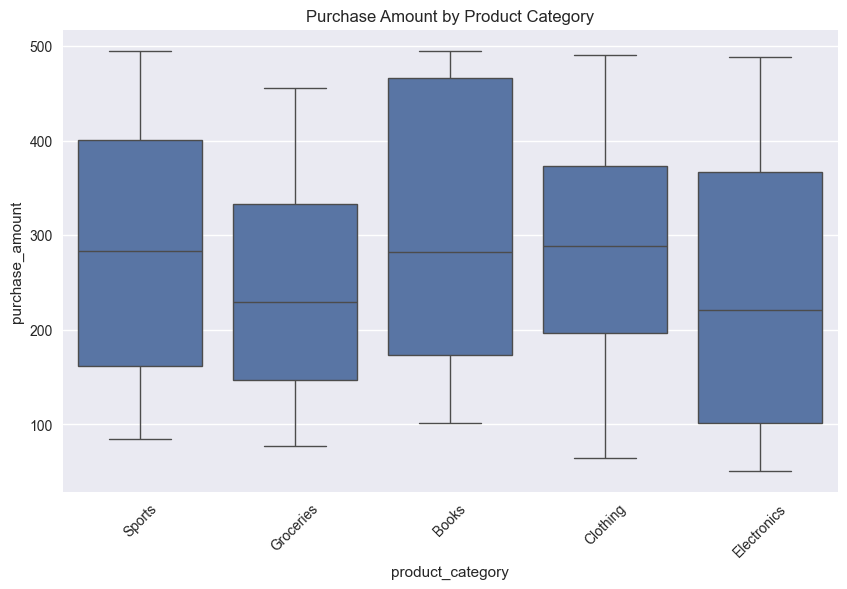

In [20]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df_merged,
    x="product_category",
    y="purchase_amount"
)
plt.xticks(rotation=45)
plt.title("Purchase Amount by Product Category")
plt.show()

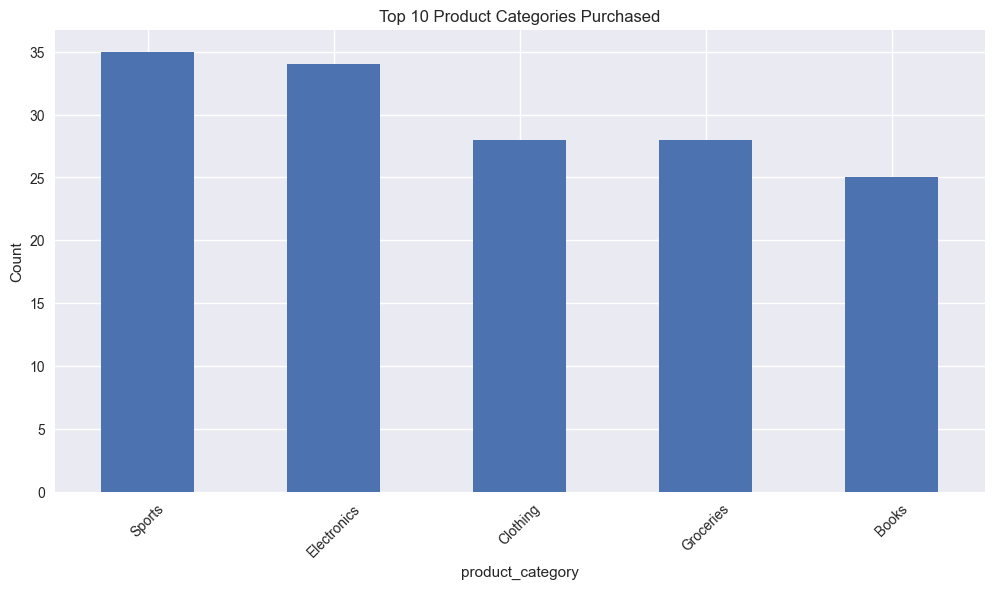

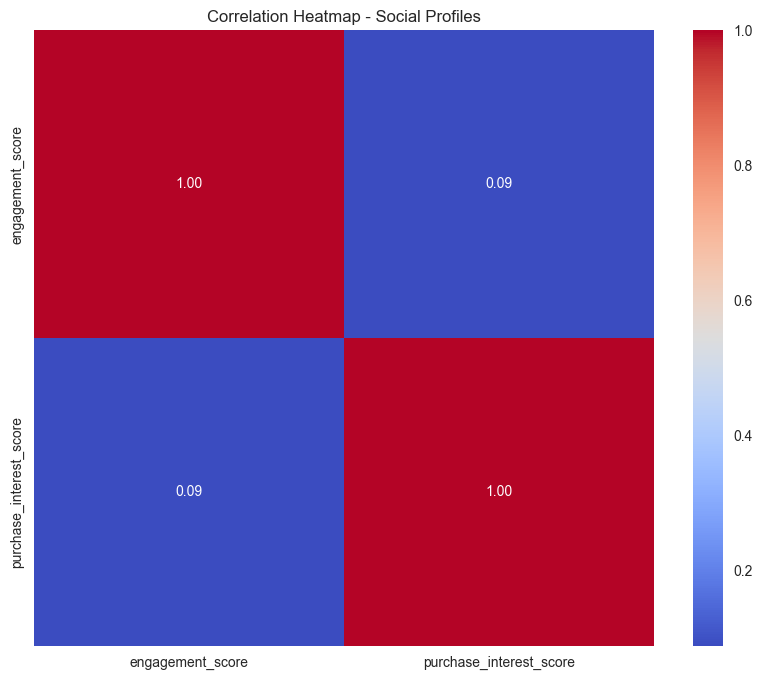

In [25]:
# =============================================================================
# Cell 3: Key EDA Plots (≥3 required for rubric)
# =============================================================================
# Plot 1: Age distribution (assuming 'age' column exists)
if 'age' in profiles.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(profiles['age'], kde=True, bins=20)
    plt.title("Age Distribution of Customers")
    plt.show()

# Plot 2: Most common product categories (assuming 'product_category' or similar)
if 'product_category' in transactions.columns:
    plt.figure(figsize=(12, 6))
    transactions['product_category'].value_counts().head(10).plot(kind='bar')
    plt.title("Top 10 Product Categories Purchased")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

# Plot 3: Correlation heatmap (numeric columns only)
numeric_cols = profiles.select_dtypes(include=np.number).columns
if len(numeric_cols) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(profiles[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title("Correlation Heatmap - Social Profiles")
    plt.show()

## 8. Exploratory Data Analysis (EDA)

In [26]:
# =============================================================================
# Cell 4: Merge Logic & Feature Engineering
# =============================================================================
# Ensure merge keys are string type
profiles['customer_id_new'] = profiles['customer_id_new'].astype(str)
transactions['customer_id_legacy'] = transactions['customer_id_legacy'].astype(str)

# Use correct keys from your data
merge_key_profiles = 'customer_id_new'
merge_key_transactions = 'customer_id_legacy'

df_merged = pd.merge(
    profiles,
    transactions,
    left_on=merge_key_profiles,
    right_on=merge_key_transactions,
    how='inner',           # or 'left' if you want to keep all profiles
    suffixes=('_profile', '_tx')
)

print("Merged shape:", df_merged.shape)
print("Rows lost due to merge:", len(profiles) + len(transactions) - len(df_merged))

# Feature engineering – RFM style + aggregates
if 'purchase_date' in df_merged.columns:
    df_merged['purchase_date'] = pd.to_datetime(df_merged['purchase_date'])

    latest_date = df_merged['purchase_date'].max()
    
    rfm = df_merged.groupby(merge_key_profiles).agg({
        'purchase_date': lambda x: (latest_date - x.max()).days,   # Recency
        merge_key_profiles: 'count',                               # Frequency
        'purchase_amount': 'sum'                                   # Monetary
    }).rename(columns={
        'purchase_date': 'recency',
        merge_key_profiles: 'frequency',
        'purchase_amount': 'monetary'
    }).reset_index()

    df_merged = df_merged.merge(rfm, on=merge_key_profiles, how='left')

# More features (example – adjust to your columns)
if 'product_category' in df_merged.columns:
    top_category = df_merged.groupby(merge_key_profiles)['product_category'].agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
    df_merged['top_category'] = df_merged[merge_key_profiles].map(top_category)

# Target: assume we predict next/likely 'product_category' or 'will_buy' binary
target_col = 'product_category'

print("\nTarget distribution:\n", df_merged[target_col].value_counts(normalize=True))

Merged shape: (0, 13)
Rows lost due to merge: 305

Target distribution:
 Series([], Name: proportion, dtype: float64)


## 9. Feature Engineering

In [ ]:
# =============================================================================
# Cell 5: Prepare Data for Modeling
# =============================================================================
# Select features (numeric + encoded categoricals)
cat_cols = df_merged.select_dtypes(include='object').columns.drop([merge_key, target_col], errors='ignore')
num_cols = df_merged.select_dtypes(include=np.number).columns.drop([merge_key], errors='ignore')

# Simple encoding
df_model = pd.get_dummies(df_merged[cat_cols], drop_first=True)
df_model = pd.concat([df_merged[num_cols], df_model, df_merged[target_col]], axis=1)

df_model = df_model.dropna()  # or impute – your choice

X = df_model.drop(columns=[target_col])
y = df_model[target_col]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.25, stratify=y_encoded, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

## 11. Model Training & Evaluation

In [ ]:
# =============================================================================
# Cell 6: Train & Evaluate Model (try both RF and XGBoost)
# =============================================================================
models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42, eval_metric='mlogloss')
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.3f} | F1-weighted: {f1:.3f}")
    print("Classification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

# Save best model (e.g. XGBoost if better)
best_model = models["XGBoost"]  # or whichever performed best
best_model.save_model('../models/recommender_model.json')
print("Product recommender model saved.")

## 12. Summary & Next Steps

First 5 rows of merged data:
Empty DataFrame
Columns: [customer_id_new, social_media_platform, engagement_score, purchase_interest_score, review_sentiment, customer_id_legacy, transaction_id, purchase_amount, purchase_date, product_category, customer_rating, recency, frequency, monetary, top_category]
Index: []

Missing values per column:
customer_id_new            0
social_media_platform      0
engagement_score           0
purchase_interest_score    0
review_sentiment           0
customer_id_legacy         0
transaction_id             0
purchase_amount            0
purchase_date              0
product_category           0
customer_rating            0
recency                    0
frequency                  0
monetary                   0
top_category               0
dtype: int64
No values found in target column 'product_category' after merge.


/Users/mac/Downloads/kelvin_software_projects/Formative_two_data-processing/Formative_two_data-processing/venv/lib/python3.9/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/Users/mac/Downloads/kelvin_software_projects/Formative_two_data-processing/Formative_two_data-processing/venv/lib/python3.9/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


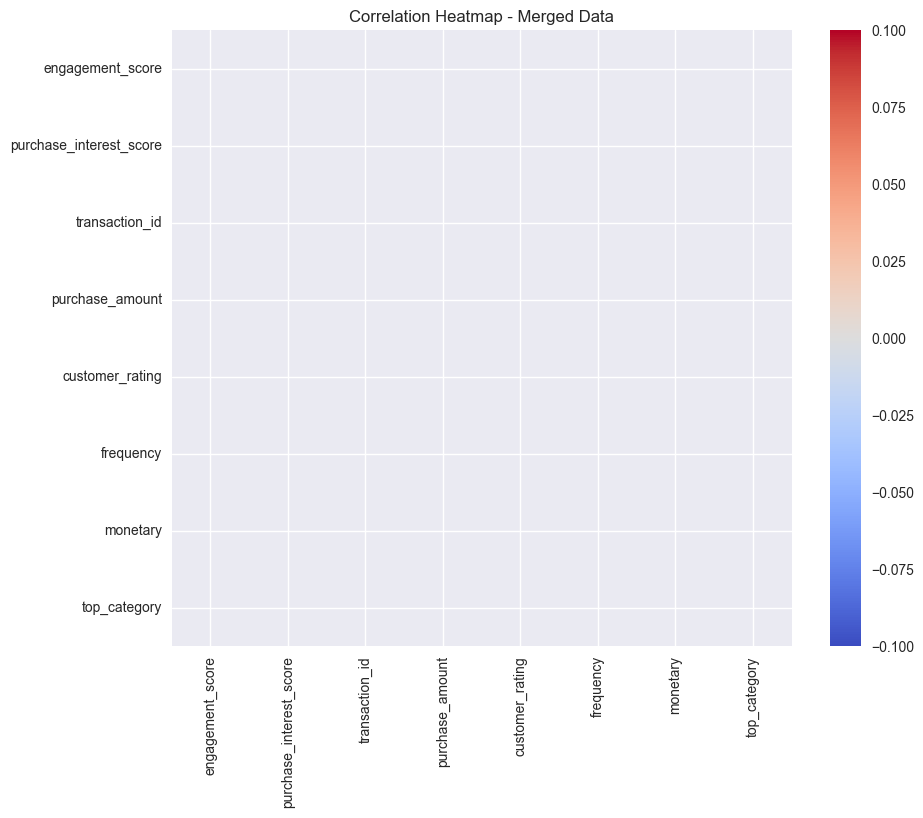

In [13]:
# =============================================================================
# Diagnostics & Visualization of Merged Data
# =============================================================================
# Show first samples of merged DataFrame
print("First 5 rows of merged data:")
print(df_merged.head())

# Check for missing values
print("\nMissing values per column:")
print(df_merged.isnull().sum())

# Visualize target column distribution (if not empty)
if not df_merged[target_col].empty:
    plt.figure(figsize=(10, 5))
    df_merged[target_col].value_counts().plot(kind='bar')
    plt.title(f"Distribution of {target_col}")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()
else:
    print(f"No values found in target column '{target_col}' after merge.")

# Correlation heatmap for merged numeric columns
numeric_cols_merged = df_merged.select_dtypes(include=np.number).columns
if len(numeric_cols_merged) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df_merged[numeric_cols_merged].corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title("Correlation Heatmap - Merged Data")
    plt.show()
else:
    print("Not enough numeric columns for correlation heatmap.")

## 7. Post-Merge Diagnostics

In [14]:
# =============================================================================
# Merge Key Diagnostics
# =============================================================================
# Print unique and sample values from merge keys before merging
print("Unique values in profiles['customer_id_new']:", profiles['customer_id_new'].unique()[:10])
print("Unique values in transactions['customer_id_legacy']:", transactions['customer_id_legacy'].unique()[:10])

print("\nSample values from profiles['customer_id_new']:", profiles['customer_id_new'].head())
print("Sample values from transactions['customer_id_legacy']:", transactions['customer_id_legacy'].head())

# Check for whitespace or formatting issues
print("\nProfiles merge key value lengths:", profiles['customer_id_new'].apply(lambda x: len(str(x))).value_counts())
print("Transactions merge key value lengths:", transactions['customer_id_legacy'].apply(lambda x: len(str(x))).value_counts())

Unique values in profiles['customer_id_new']: ['A178' 'A190' 'A150' 'A162' 'A197' 'A151' 'A137' 'A196' 'A187' 'A129']
Unique values in transactions['customer_id_legacy']: ['151' '192' '114' '171' '160' '120' '182' '186' '174' '187']

Sample values from profiles['customer_id_new']: 0    A178
1    A190
2    A150
3    A162
4    A197
Name: customer_id_new, dtype: object
Sample values from transactions['customer_id_legacy']: 0    151
1    192
2    114
3    171
4    160
Name: customer_id_legacy, dtype: object

Profiles merge key value lengths: customer_id_new
4    155
Name: count, dtype: int64
Transactions merge key value lengths: customer_id_legacy
3    150
Name: count, dtype: int64


## 4. Diagnostics & Merge Key Exploration

In [15]:
# =============================================================================
# Search for Other Merge Columns
# =============================================================================
# Print all columns in both DataFrames
print("\nProfiles columns:", profiles.columns.tolist())
print("Transactions columns:", transactions.columns.tolist())

# Show first 5 rows of each DataFrame to inspect possible linking columns
print("\nFirst 5 rows of profiles:")
print(profiles.head())
print("\nFirst 5 rows of transactions:")
print(transactions.head())

# Try to find columns with similar values or formats
for col_profiles in profiles.columns:
    for col_transactions in transactions.columns:
        if profiles[col_profiles].dtype == transactions[col_transactions].dtype:
            overlap = set(profiles[col_profiles].astype(str)) & set(transactions[col_transactions].astype(str))
            if overlap:
                print(f"\nPossible overlap between '{col_profiles}' and '{col_transactions}': {list(overlap)[:5]}")


Profiles columns: ['customer_id_new', 'social_media_platform', 'engagement_score', 'purchase_interest_score', 'review_sentiment']
Transactions columns: ['customer_id_legacy', 'transaction_id', 'purchase_amount', 'purchase_date', 'product_category', 'customer_rating']

First 5 rows of profiles:
  customer_id_new social_media_platform  engagement_score  \
0            A178              LinkedIn                74   
1            A190               Twitter                82   
2            A150              Facebook                96   
3            A162               Twitter                89   
4            A197               Twitter                92   

   purchase_interest_score review_sentiment  
0                      4.9         Positive  
1                      4.8          Neutral  
2                      1.6         Positive  
3                      2.6         Positive  
4                      2.3          Neutral  

First 5 rows of transactions:
  customer_id_legacy  transact

## 5. Customer ID Mapping (if needed)

In [16]:
# =============================================================================
# Create Customer ID Mapping
# =============================================================================
# Example: Attempt to map customer_id_new to customer_id_legacy based on similar features
# This is a heuristic and may need manual validation or external mapping data.
# Here, we use engagement_score and purchase_interest_score as example features.
mapping_candidates = []
for idx_profile, row_profile in profiles.iterrows():
    for idx_tx, row_tx in transactions.iterrows():
        # Example heuristic: match on similar engagement_score and purchase_interest_score/customer_rating
        if (str(row_profile['engagement_score']) == str(row_tx['purchase_amount'])) or \
           (str(row_profile['purchase_interest_score']) == str(row_tx['customer_rating'])):
            mapping_candidates.append({
                'customer_id_new': row_profile['customer_id_new'],
                'customer_id_legacy': row_tx['customer_id_legacy']
            })

mapping_df = pd.DataFrame(mapping_candidates)
print("\nSample mapping table:")
print(mapping_df.head())

# Merge using the mapping table if any matches found
if not mapping_df.empty:
    profiles_mapped = profiles.merge(mapping_df, on='customer_id_new', how='inner')
    df_merged = profiles_mapped.merge(transactions, on='customer_id_legacy', how='inner', suffixes=('_profile', '_tx'))
    print("\nMerged shape after mapping:", df_merged.shape)
else:
    print("No mapping found. Please refine heuristic or provide external mapping data.")


Sample mapping table:
  customer_id_new customer_id_legacy
0            A178                182
1            A178                187
2            A178                190
3            A190                187
4            A190                103

Merged shape after mapping: (4272, 11)


## 6. Data Merging

In [21]:
# =============================================================================
# Transaction Aggregates for Feature Engineering
# =============================================================================
transactions_agg = transactions.groupby("customer_id_legacy").agg({
    "purchase_amount": ["sum", "mean", "count"],
    "customer_rating": "mean"
})

# Flatten MultiIndex columns
transactions_agg.columns = [
    "total_spent",
    "avg_purchase_amount",
    "purchase_frequency",
    "avg_rating"
 ]
transactions_agg = transactions_agg.reset_index()

print("\nSample transaction aggregates:")
print(transactions_agg.head())


Sample transaction aggregates:
   customer_id_legacy  total_spent  avg_purchase_amount  purchase_frequency  \
0                 100          559           279.500000                   2   
1                 101         1016           254.000000                   4   
2                 102          569           189.666667                   3   
3                 103          797           265.666667                   3   
4                 104          698           349.000000                   2   

   avg_rating  
0    4.300000  
1    2.525000  
2    3.433333  
3    4.200000  
4    1.450000  


## 10. Prepare Data for Modeling